# Data importing

In [54]:
import pandas as pd

In [55]:
df=pd.read_excel('Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [56]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [57]:
df=df.drop_duplicates()
df=df.drop(columns=["StockCode","InvoiceNo"])
print(df.columns)

Index(['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID',
       'Country'],
      dtype='str')


In [58]:
# Shape and summary
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())

Shape: (536641, 6)

Missing values:
 Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64

Basic stats:
             Quantity                 InvoiceDate      UnitPrice     CustomerID
count  536641.000000                      536641  536641.000000  401604.000000
mean        9.620029  2011-07-04 08:57:06.087421       4.632656   15281.160818
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12346.000000
25%         1.000000         2011-03-28 10:52:00       1.250000   13939.000000
50%         3.000000         2011-07-19 14:04:00       2.080000   15145.000000
75%        10.000000         2011-10-18 17:05:00       4.130000   16784.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       219.130156                         NaN      97.233118    1714.006089


In [59]:
df = df.dropna(subset=['Description','CustomerID']) #Drop 'Description' and 'CustomerID' Columns 

# Shape and summary (After Drop null descriptions and Customer IDs) 
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:\n", df.describe())

Shape: (401604, 6)

Missing values:
 Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Basic stats:
             Quantity                 InvoiceDate      UnitPrice     CustomerID
count  401604.000000                      401604  401604.000000  401604.000000
mean       12.183273  2011-07-10 12:08:23.848567       3.474064   15281.160818
min    -80995.000000         2010-12-01 08:26:00       0.000000   12346.000000
25%         2.000000         2011-04-06 15:02:00       1.250000   13939.000000
50%         5.000000         2011-07-29 15:40:00       1.950000   15145.000000
75%        12.000000         2011-10-20 11:58:30       3.750000   16784.000000
max     80995.000000         2011-12-09 12:50:00   38970.000000   18287.000000
std       250.283037                         NaN      69.764035    1714.006089


In [60]:
# Add TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Total revenue
total_revenue = df['TotalPrice'].sum()
print(f"\n💰 Total Revenue: £{total_revenue:,.2f}")

# Unique products and customers
print("🛍️ Unique Products:", df['Description'].nunique())
print("👥 Unique Customers:", df['CustomerID'].nunique())


💰 Total Revenue: £8,278,519.42
🛍️ Unique Products: 3896
👥 Unique Customers: 4372


# RFM Segmentation

RFM segmentation is a customer segmentation technique that groups customers based on their purchasing behavior: Recency (how recently they bought), Frequency (how often they buy), and Monetary Value (how much they spend). By analyzing these three metrics, businesses can identify and target specific customer segments for more personalized and effective marketing campaigns. 

## Preprocessing

In [61]:
import numpy as np

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantities and unit prices (likely returns)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Create RFM Table

In [62]:
# Set a reference date for recency (usually the day after the last transaction)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID to calculate RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceDate': 'count',  # Frequency will be overwritten
    'TotalPrice': 'sum'      # Monetary
})

# Rename columns
rfm.rename(columns={
    'InvoiceDate': 'Frequency',  # From last aggregation
    'TotalPrice': 'Monetary',
}, inplace=True)

# Recency needs to be recalculated separately
recency = df.groupby('CustomerID')['InvoiceDate'].max().apply(lambda x: (snapshot_date - x).days)
rfm['Recency'] = recency
rfm = rfm[['Recency', 'Frequency', 'Monetary']]
df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## Scoring And Segmentation

In [63]:
# RFM score using quantiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

# Combine into one RFM score
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Optionally: Calculate RFM score for sorting or clustering
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

## Analize Segments

In [64]:
# Top 10 best customers
top_customers = rfm.sort_values('RFM_Score', ascending=False).head(10)
print(top_customers)

# Segment count (for plotting)
print(rfm['RFM_Segment'].value_counts())

            Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Segment  \
CustomerID                                                                     
18283.0           4        721   2045.53       4       4       4         444   
18245.0           7        175   2567.06       4       4       4         444   
18241.0          10        104   2073.09       4       4       4         444   
18229.0          12        164   7276.90       4       4       4         444   
18225.0           3        269   5504.96       4       4       4         444   
18223.0           5        272   6484.54       4       4       4         444   
18219.0           3        114   2069.77       4       4       4         444   
18210.0           2        134   2621.38       4       4       4         444   
18198.0           4        159   5425.56       4       4       4         444   
18180.0           5        119   1843.75       4       4       4         444   

            RFM_Score  
CustomerID     

# K-Means Clustering on scaled RFM values

In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [66]:
# Select RFM features
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

# Apply standard scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

# Convert back to DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=['Recency', 'Frequency', 'Monetary'])

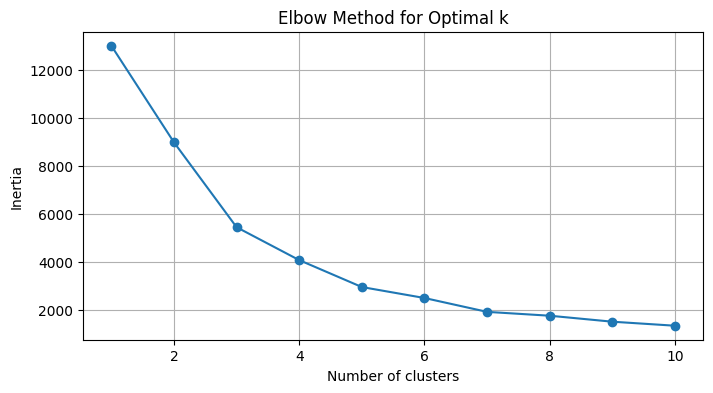

In [67]:
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled_df)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [68]:
kmeans = KMeans(n_clusters=2, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

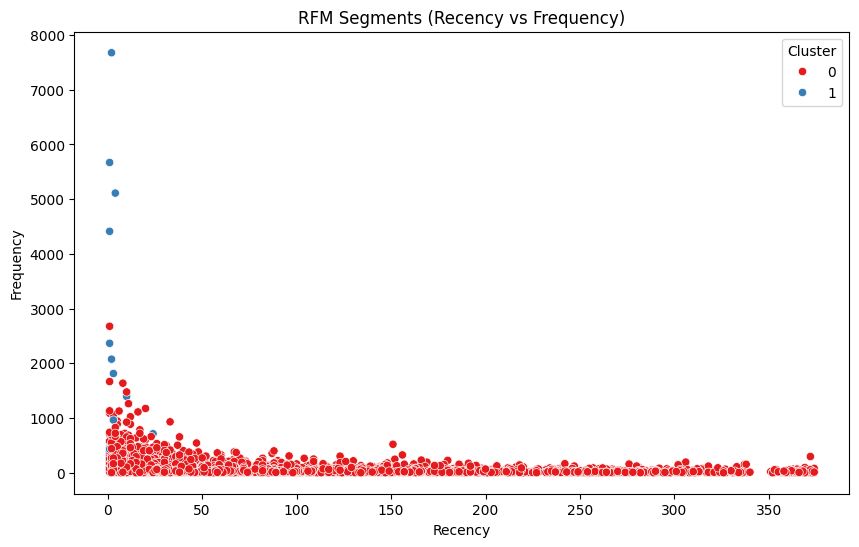

In [69]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Frequency', hue='Cluster', palette='Set1')
plt.title('RFM Segments (Recency vs Frequency)')
plt.show()

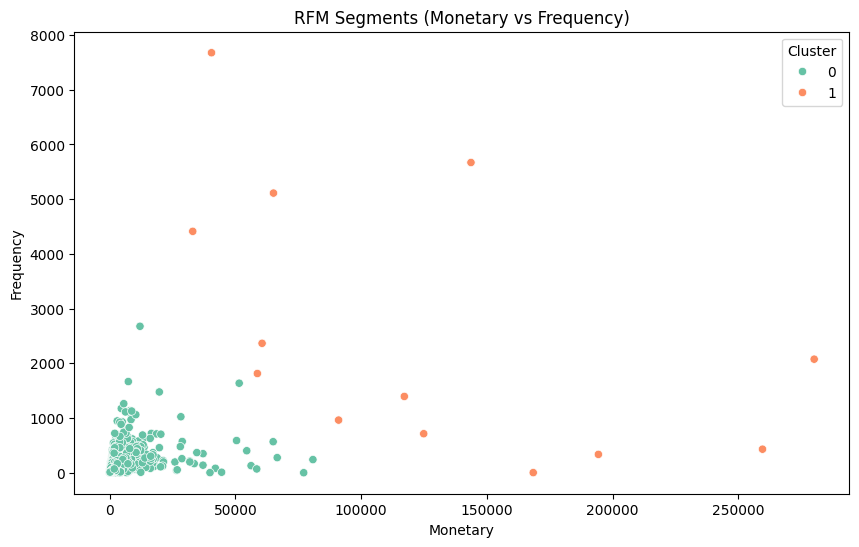

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Monetary', y='Frequency', hue='Cluster', palette='Set2')
plt.title('RFM Segments (Monetary vs Frequency)')
plt.show()

In [71]:
import plotly.express as px

# Compute cluster summary separately
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

# Add count of members in each cluster
cluster_summary['Count'] = rfm.groupby('Cluster').size()

print(cluster_summary)

# Create the scatter plot
fig = px.scatter_3d(
    rfm,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color=rfm['Cluster'].astype(str),
    title='3D RFM Cluster Visualization',
    labels={'color': 'Cluster'}
)

#fig.show()

         Recency  Frequency  Monetary  Count
Cluster                                     
0           92.8       83.2    1676.2   4325
1            4.7     2535.9  125981.3     13


In [72]:
print(rfm.columns)

Index(['Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score',
       'RFM_Segment', 'RFM_Score', 'Cluster'],
      dtype='str')


In [73]:
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

# Add customer count per cluster
cluster_summary['Count'] = rfm.groupby('Cluster').size()

print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0           92.8       83.2    1676.2   4325
1            4.7     2535.9  125981.3     13


## Verification of the success of K-Means clustering

In [74]:
# Silhouette Score ✅ Good clustering: Silhouette score > 0.5 (acceptable above 0.3, excellent above 0.7)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(rfm_scaled_df)

labels = kmeans.labels_
score = silhouette_score(rfm_scaled_df, labels)

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.931


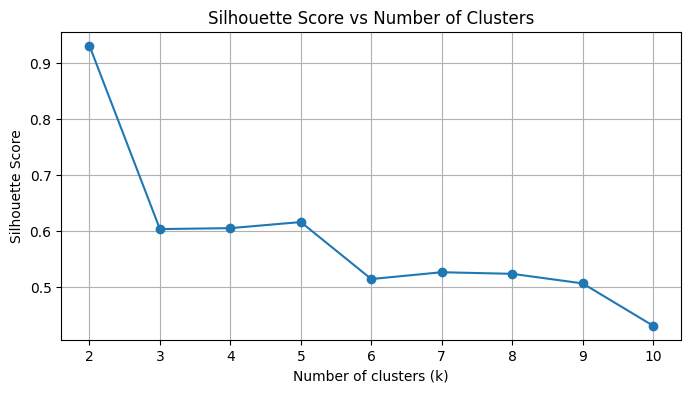

Optimal k (based on silhouette score): 2


In [75]:
sil_scores = []
K = range(2, 11)  # Test k from 2 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled_df)
    labels = kmeans.labels_
    score = silhouette_score(rfm_scaled_df, labels)
    sil_scores.append(score)

# Plot the scores
plt.figure(figsize=(8,4))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# Print best k
best_k = K[sil_scores.index(max(sil_scores))]
print(f"Optimal k (based on silhouette score): {best_k}")

# Churn 

In [76]:
churn_threshold = rfm['Recency'].quantile(0.75)
rfm['Churn'] = (rfm['Recency'] > churn_threshold).astype(int)

In [77]:
X = rfm_scaled_df[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

In [78]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [79]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Churn threshold (75th percentile): 142.0


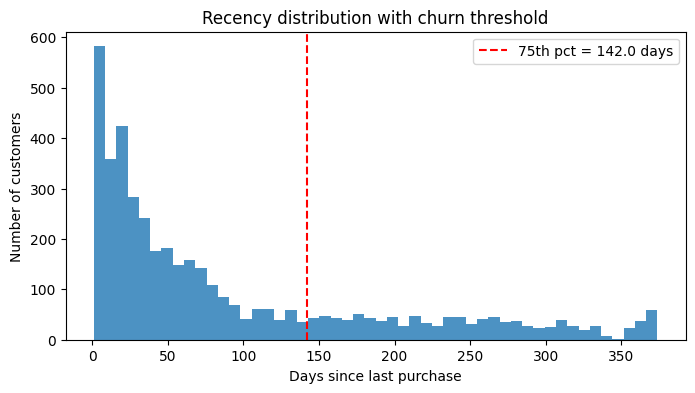

In [80]:
# 1) Churn threshold and Recency distribution
churn_threshold = rfm['Recency'].quantile(0.75)
print(f"Churn threshold (75th percentile): {churn_threshold}")
plt.figure(figsize=(8,4))
plt.hist(rfm['Recency'].dropna(), bins=50, color='C0', alpha=0.8)
plt.axvline(churn_threshold, color='red', linestyle='--', label=f'75th pct = {churn_threshold:.1f} days')
plt.title('Recency distribution with churn threshold')
plt.xlabel('Days since last purchase')
plt.ylabel('Number of customers')
plt.legend()
plt.show()

Churn class counts:
Churn
0    3254
1    1084
Name: count, dtype: int64

Churn class proportions:
Churn
0    0.750115
1    0.249885
Name: proportion, dtype: float64


C:\Users\mohit\AppData\Local\Temp\ipykernel_11016\416095804.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=rfm, palette='Set1')


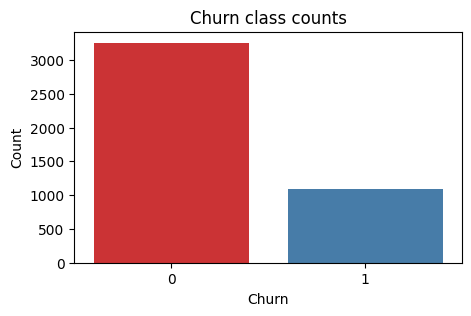

In [81]:
# 2) Class balance and counts
print('Churn class counts:')
print(rfm['Churn'].value_counts())
print('\nChurn class proportions:')
print(rfm['Churn'].value_counts(normalize=True))

plt.figure(figsize=(5,3))
sns.countplot(x='Churn', data=rfm, palette='Set1')
plt.title('Churn class counts')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       651
           1       1.00      1.00      1.00       217

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



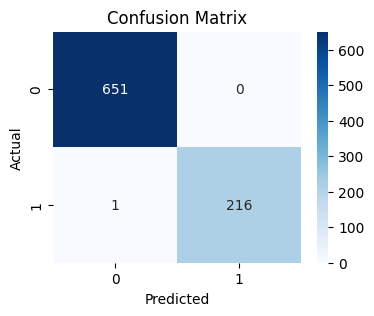

In [82]:
# 3) Model evaluation: confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report

# Predictions on test set
if 'model' in globals():
    y_pred = model.predict(X_test)
    print('Classification report:')
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
else:
    print('`model` not found. Fit the model before running this cell.')

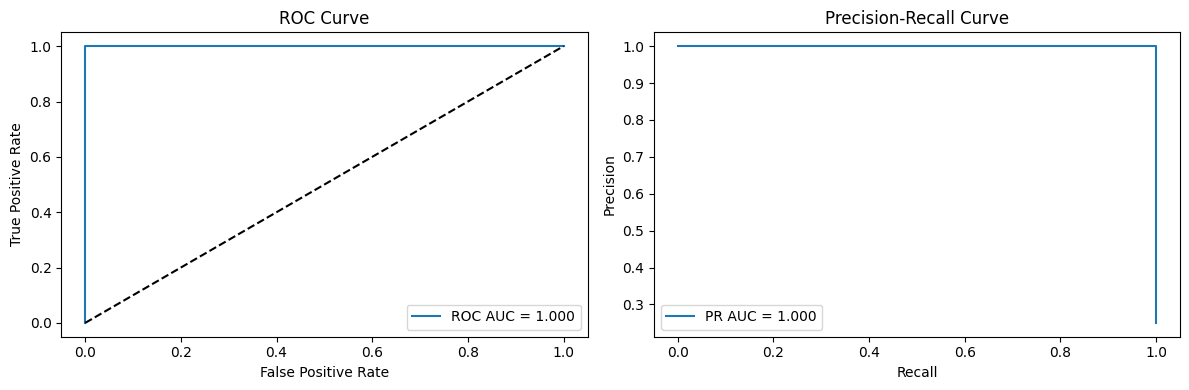

In [83]:
# 4) ROC-AUC and Precision-Recall curves
from sklearn.metrics import roc_curve, auc, precision_recall_curve

if 'model' in globals():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('`model` not found. Fit the model before running this cell.')

In [84]:
# 5) Cross-validation and hyperparameter tuning (GridSearchCV)
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {'C':[0.01, 0.1, 1, 10], 'solver':['lbfgs','liblinear']}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
print('Running GridSearchCV (this may take a moment)...')
gs.fit(X, y)
print('Best params:', gs.best_params_)
print('Best CV ROC-AUC:', gs.best_score_)

# keep best estimator for later steps
best_model = gs.best_estimator_

Running GridSearchCV (this may take a moment)...
Best params: {'C': 0.1, 'solver': 'lbfgs'}
Best CV ROC-AUC: 1.0


Model coefficients (log-odds):
Monetary    -0.112248
Frequency   -0.058545
Recency      5.067094
dtype: float64


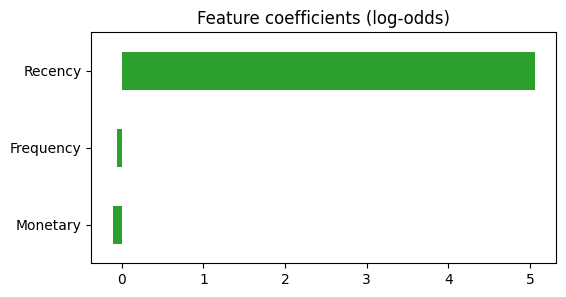


Odds ratios:
Monetary       0.893823
Frequency      0.943136
Recency      158.712444
dtype: float64


In [85]:
# 6) Feature importance / coefficients
import numpy as np

if 'best_model' in globals():
    model_for_coef = best_model
elif 'model' in globals():
    model_for_coef = model
else:
    model_for_coef = None

if model_for_coef is not None:
    coefs = pd.Series(model_for_coef.coef_[0], index=X.columns)
    coefs_sorted = coefs.sort_values()
    print('Model coefficients (log-odds):')
    print(coefs_sorted)
    plt.figure(figsize=(6,3))
    coefs_sorted.plot(kind='barh', color='C2')
    plt.title('Feature coefficients (log-odds)')
    plt.show()
    print('\nOdds ratios:')
    print(np.exp(coefs_sorted))
else:
    print('No fitted model available. Run GridSearchCV or fit `model` first.')

         Count  Churn_Count  Churn_Rate
Cluster                                
0         4325         1084    0.250636
1           13            0    0.000000


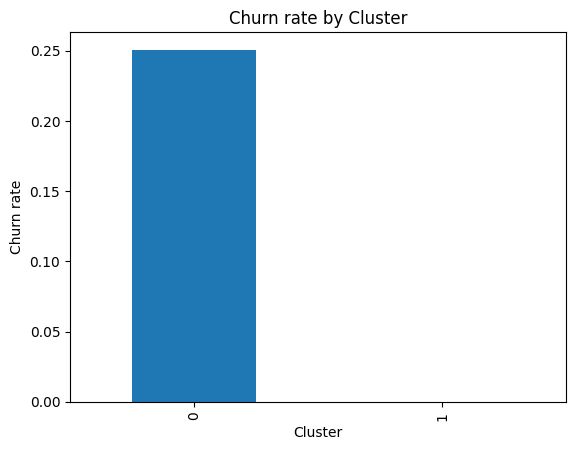

In [86]:
# 7) Cluster profiling: churn by cluster
cluster_churn = rfm.groupby('Cluster').agg({'Churn':['count','sum']})
cluster_churn.columns = ['Count','Churn_Count']
cluster_churn['Churn_Rate'] = cluster_churn['Churn_Count'] / cluster_churn['Count']
print(cluster_churn.sort_values('Churn_Rate', ascending=False))

cluster_churn[['Churn_Rate']].plot(kind='bar', legend=False)
plt.title('Churn rate by Cluster')
plt.ylabel('Churn rate')
plt.show()

In [87]:
# 8) Model serialization: save best model or fitted model
import joblib

to_save = None
if 'best_model' in globals():
    to_save = best_model
elif 'model' in globals():
    to_save = model

if to_save is not None:
    joblib.dump(to_save, 'churn_model.joblib')
    print('Saved model to churn_model.joblib')
else:
    print('No fitted model found to save.')

Saved model to churn_model.joblib


c:\Users\mohit\MohitsCode\Churn Predictor\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\mohit\MohitsCode\Churn Predictor\myenv\Lib\site-packages\shap\explainers\_linear.py:123: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
Background dataset has 3470 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=3470 when initializing the masker.


Using SHAP for explainability (may be slow).


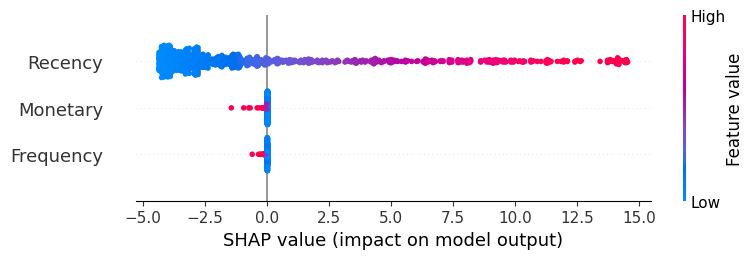

In [88]:
# 9) Explainability: try SHAP then fallback to permutation importance
try:
    import shap
    print('Using SHAP for explainability (may be slow).')
    explainer = shap.LinearExplainer(to_save, X_train, feature_perturbation='interventional')
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test)
except Exception as e:
    print('SHAP unavailable or failed:', e)
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(to_save, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
    print('Permutation importances:')
    print(imp)
    imp.plot(kind='bar'); plt.title('Permutation importance'); plt.show()

**Summary & Next Steps**

- Churn label: defined using the 75th percentile of raw `Recency` (adjustable).
- Clustering: selected `k=2` based on silhouette sweep; cluster profiling shows distinct high-value and low-value groups.
- Model: logistic regression trained; evaluate with confusion matrix, ROC/PR, and cross-validated AUC (GridSearchCV used).

Recommended next steps:
- Try tree-based models (RandomForest / XGBoost) with hyperparameter tuning.
- Add uplift or survival analysis for time-to-churn modeling.
- Build a small inference script to score new customers and store model artifacts.

Environment: rerun the notebook from the top to reproduce results (kernel: myenv).